In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
class BVP:
    def __init__(self, patient, quadrant, signal, features, id):
        self.patient = patient
        self.quadrant = quadrant
        self.signal = signal
        self.features = features
        self.id = id

MAX_VID_LENGTH = 100

In [3]:
patients = list(range(1, 62))
patients.remove(23)

quadrants = [
    "Q1_1",
    "Q1_2",
    "Q2_1",
    "Q2_2",
    "Q3_1",
    "Q3_2",
    "Q4_1",
    "Q4_2",
    "Q5_1",
    "Q5_2",
    "Q6_1",
    "Q6_2",
    "Q7_1",
    "Q7_2",
    "Q8_1",
    "Q8_2",
    "Q9_1",
    "Q9_2"
]

In [ ]:
bvp_path = "../BVPs"

failed_masks = [
    [2, "Q1_1"],
    [9, "Q7_2"],
    [12, "Q4_1"],
    [14, "Q1_2"],
    [52, "Q7_2"],
    [53, "Q4_2"],
    [60, "Q3_2"]
]

In [5]:
def cut_bvp(bvp, t_start, t_end, fs=60):
    n = len(bvp)

    # Convert time to sample indices
    n_start = int(t_start * fs)
    n_end = int(t_end * fs)

    # Clamp to valid range
    n_start = max(0, min(n_start, n))
    n_end = max(0, min(n_end, n))

    return bvp[n_start:n_end]

In [6]:
def cut_relevant_bvp(data, quadrant, fs=60):

    if quadrant == "Q1_2":

        a = 1
        data = cut_bvp(data, 20, MAX_VID_LENGTH, fs)

    elif quadrant == "Q3_2":

        data = cut_bvp(data, 38, MAX_VID_LENGTH, fs)
    
    return data


In [7]:
BVPs = []

fs = 60

for patient in patients:

    for quadrant in quadrants:

        if [patient, quadrant] in failed_masks:
            print(f"Skipping Patient_{patient}, {quadrant}")
            continue

        data = np.load(f"{bvp_path}/Patient_{patient}/{quadrant}.npy")

        data = cut_relevant_bvp(data, quadrant, fs)

        id = f"{patient}{quadrant}"

        bvp = BVP(patient, quadrant, data, [], id)

        BVPs.append(bvp)

        #print(f"Patient_{patient}, {quadrant}: {data.shape}")

print(f"Loaded {len(BVPs)} BVP signals")

Skipping Patient_2, Q1_1
Skipping Patient_52, Q7_2
Skipping Patient_53, Q4_2
Loaded 1077 BVP signals


In [8]:
from scipy.signal import find_peaks, czt

In [9]:
def compute_bvp_features_article(bvp_signal, fs, patient=None, quadrant=None):
    """
    Compute PPG features (14 features from paper) using CZT.
    Includes debug prints when something fails.
    """

    bvp = np.asarray(bvp_signal)

    if len(bvp) < fs * 2:
        print(f"[SHORT SIGNAL] Patient {patient}, {quadrant}")
        return None

    # ---- Remove DC ----
    bvp = bvp - np.mean(bvp)

    features = {}

    # --------------------------------------------------
    # 1. Peak detection → RR intervals
    # --------------------------------------------------
    min_dist = int(0.4 * fs)
    peaks, _ = find_peaks(bvp, distance=min_dist)

    if len(peaks) < 3:
        print(f"[PEAK DETECTION FAILED] Patient {patient}, {quadrant}")
        return None

    rr = np.diff(peaks) / fs
    hr = 60.0 / rr

    # --------------------------------------------------
    # 2. HR features
    # --------------------------------------------------
    features["hr_mean"] = np.mean(hr)
    features["hr_std"] = np.std(hr)

    # --------------------------------------------------
    # 3. HRV time-domain features
    # --------------------------------------------------
    features["rr_mean"] = np.mean(rr)
    features["rr_std"] = np.std(rr)

    diff_rr = np.diff(rr)

    if len(diff_rr) > 0:
        features["rmssd"] = np.sqrt(np.mean(diff_rr ** 2))
        features["sdsd"] = np.std(diff_rr)
        features["pnn50"] = np.sum(np.abs(diff_rr) > 0.05) / len(diff_rr)
    else:
        print(f"[RR DIFFERENCES FAILED] Patient {patient}, {quadrant}")
        features["rmssd"] = np.nan
        features["sdsd"] = np.nan
        features["pnn50"] = np.nan

    # --------------------------------------------------
    # 4. TINN
    # --------------------------------------------------
    try:
        hist, bin_edges = np.histogram(rr, bins=20)
        features["tinn"] = bin_edges[-1] - bin_edges[0]
    except Exception:
        print(f"[TINN FAILED] Patient {patient}, {quadrant}")
        features["tinn"] = np.nan

    # --------------------------------------------------
    # 5. Poincaré
    # --------------------------------------------------
    try:
        if len(diff_rr) > 0:
            sd1 = np.sqrt(np.var(diff_rr) / 2)
            sd2 = np.sqrt(2 * np.var(rr) - 0.5 * np.var(diff_rr))

            features["sd1"] = sd1
            features["sd2"] = sd2
            features["sd1_sd2"] = sd1 / sd2 if sd2 != 0 else np.nan
        else:
            raise ValueError
    except Exception:
        print(f"[POINCARE FAILED] Patient {patient}, {quadrant}")
        features["sd1"] = np.nan
        features["sd2"] = np.nan
        features["sd1_sd2"] = np.nan

    # --------------------------------------------------
    # 6. LF / HF using CZT
    # --------------------------------------------------
    try:
        rr_times = np.cumsum(rr)
        rr_times = np.insert(rr_times, 0, 0)

        fs_interp = 4.0
        t_uniform = np.arange(0, rr_times[-1], 1 / fs_interp)

        rr_interp = np.interp(
            t_uniform,
            rr_times,
            np.append(rr, rr[-1])
        )

        fmin = 0.04
        fmax = 0.4
        n_bins = 256

        w = np.exp(-1j * 2 * np.pi * (fmax - fmin) / (n_bins * fs_interp))
        a = np.exp(1j * 2 * np.pi * fmin / fs_interp)

        spectrum = czt(rr_interp, n_bins, w, a)
        power = np.abs(spectrum) ** 2
        freqs = np.linspace(fmin, fmax, n_bins)

        lf_band = (freqs >= 0.04) & (freqs < 0.15)
        hf_band = (freqs >= 0.15) & (freqs < 0.4)

        lf = np.sum(power[lf_band])
        hf = np.sum(power[hf_band])

        features["lf"] = lf
        features["hf"] = hf
        features["lf_hf"] = lf / hf if hf > 0 else np.nan

    except Exception:
        print(f"[LF/HF FAILED] Patient {patient}, {quadrant}")
        features["lf"] = np.nan
        features["hf"] = np.nan
        features["lf_hf"] = np.nan

    return features

In [10]:
bvp = BVPs[1]
fs = 60

features = compute_bvp_features_article(bvp.signal, fs, bvp.patient, bvp.quadrant)

In [11]:
print(bvp.patient, bvp.quadrant)
print(features)

1 Q1_2
{'hr_mean': 73.91783008099833, 'hr_std': 3.370927356598916, 'rr_mean': 0.8133333333333334, 'rr_std': 0.035590260840104394, 'rmssd': 0.046717659215115705, 'sdsd': 0.04616837959444125, 'pnn50': 0.35714285714285715, 'tinn': 0.13333333333333341, 'sd1': 0.03264597428762404, 'sd2': 0.038308924497369105, 'sd1_sd2': 0.8521767372995821, 'lf': 8939.439001810815, 'hf': 1312.1471706452562, 'lf_hf': 6.812832586008468}


In [12]:
valid = []
failed = []

for bvp in BVPs:  # use a copy to safely remove items

    print(f"Computing Features for Patient_{bvp.patient}...", end="\r", flush=True)
    
    try:
        # Use the new windowed feature extraction
        feats = compute_bvp_features_article(bvp.signal, fs, bvp.patient, bvp.quadrant)

        if feats is None or feats == []:
            print(f"Failed: Patient_{bvp.patient}, {bvp.quadrant}")
            failed.append(f"Patient_{bvp.patient}, {bvp.quadrant}")
            BVPs.remove(bvp)  # remove problematic signal
        else:
            bvp.features = feats
            valid.append(f"Patient_{bvp.patient}, {bvp.quadrant}")

    except Exception as e:
        print(f"Error for Patient_{bvp.patient}, {bvp.quadrant}: {e}")
        failed.append(f"Patient_{bvp.patient}, {bvp.quadrant}")
        BVPs.remove(bvp)

print(f"Extracted features for {len(valid)} videos")
print(f"Failed: {failed}")

[SHORT SIGNAL] Patient 14, Q1_214...
Failed: Patient_14, Q1_2
[SHORT SIGNAL] Patient 60, Q3_260...
Failed: Patient_60, Q3_2
Extracted features for 1073 videos..
Failed: ['Patient_14, Q1_2', 'Patient_60, Q3_2']


In [13]:
print(failed)

['Patient_14, Q1_2', 'Patient_60, Q3_2']


In [14]:
for bvp in BVPs:

    try:

        if (f"Patient_{bvp.patient}, {bvp.quadrant}") not in failed:
            feats = bvp.features
            #print(bvp.patient, bvp.quadrant)
            for jdx in range(0, 14):
                dummie =  list(feats.values())[jdx] == np.nan

    except Exception as e:

        print(f"Not loaded on Patient_{bvp.patient}, {bvp.quadrant}")


Not loaded on Patient_14, Q2_1
Not loaded on Patient_60, Q4_1


In [15]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_selection import SelectFpr, f_classif

In [16]:
# VALENCE

def get_label(path):
    q = path.split("_")[0]

    if q in ["Q1", "Q4", "Q7"]:
        return "Negative Valence"
    
    if q in ["Q2", "Q5", "Q8"]:
        return "Neutral Valence"
    
    else:
        return "Positive Valence"

# label_map = {
#     "Q1": "Q1: ↑Arousal ↓Val",
#     "Q2": "Q2: ↑Arousal -Val",
#     "Q3": "Q3: ↑Arousal ↑Val",
#     "Q4": "Q4: -Arousal ↓Val",
#     "Q5": "Q5: -Arousal -Val",
#     "Q6": "Q6: -Arousal ↑Val",
#     "Q7": "Q7: ↓Arousal ↓Val",
#     "Q8": "Q8: ↓Arousal -Val",
#     "Q9": "Q9: ↓Arousal ↑Val",
# }

# def get_label(path):
#     q = path.split("_")[0]  # "Q3_2" → "Q3"
#     return label_map[q]

In [17]:
X = []
y = []
groups = []

for bvp in BVPs:
    if bvp is None or bvp.features == []:
        print("Error: Patient", bvp.patient, bvp.quadrant)
        continue
    
    feat_values = list(bvp.features.values())
    X.append(feat_values)
    y.append(get_label(bvp.quadrant))
    groups.append(bvp.id)  
    

X = np.array(X)
y = np.array(y)

print(X.shape, y.shape)
print(np.unique(y, return_counts=True))
print("Example of data: ", X[0])

Error: Patient 14 Q2_1
Error: Patient 60 Q4_1
(1073, 14) (1073,)
(array(['Negative Valence', 'Neutral Valence', 'Positive Valence'],
      dtype='<U16'), array([355, 359, 359], dtype=int64))
Example of data:  [9.26717515e+01 2.87402265e+01 7.03645833e-01 1.83746427e-01
 2.14400891e-01 2.14333471e-01 7.41935484e-01 5.66666667e-01
 1.51556651e-01 2.11083113e-01 7.17995147e-01 5.94819513e+03
 3.30514666e+03 1.79967661e+00]


In [18]:
from sklearn.feature_selection import f_classif
import numpy as np

# X = feature matrix (n_samples, n_features)
# y = labels

F_values, p_values = f_classif(X, y)

# Feature names (important!)
feature_names = list(BVPs[0].features.keys())

# Combine everything
anova_results = list(zip(feature_names, F_values, p_values))

# Sort by F-score (descending)
anova_results.sort(key=lambda x: x[1], reverse=True)

# Print nicely
for name, f, p in anova_results:
    print(f"{name:15} | F = {f:.3f} | p = {p:.5f}")

lf              | F = 40.550 | p = 0.00000
hf              | F = 10.819 | p = 0.00002
lf_hf           | F = 4.661 | p = 0.00965
tinn            | F = 1.976 | p = 0.13908
sd1_sd2         | F = 0.811 | p = 0.44483
pnn50           | F = 0.115 | p = 0.89159
rr_mean         | F = 0.081 | p = 0.92199
rmssd           | F = 0.070 | p = 0.93231
sdsd            | F = 0.070 | p = 0.93260
sd1             | F = 0.070 | p = 0.93260
sd2             | F = 0.023 | p = 0.97693
rr_std          | F = 0.018 | p = 0.98185
hr_std          | F = 0.014 | p = 0.98613
hr_mean         | F = 0.011 | p = 0.98875


In [19]:
feature_names = list(bvp.features.keys())

In [20]:
num_folds = 5
feat_p_cutoff = 0.05

In [21]:
from sklearn.feature_selection import SelectFpr, f_classif

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("anova", SelectFpr(score_func=f_classif, alpha=feat_p_cutoff)),  # FEATURE IMPORTANCE CUTOFF
    ("clf", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

cv = StratifiedGroupKFold(n_splits=num_folds)

classif_reports = []
conf_matrix = []
f1_scores = []

from collections import Counter
print("Class distribution:", Counter(y))

for fold, (train_idx, test_idx) in enumerate(cv.split(X, y, groups)):
    print(f"Fold {fold}")

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    #print("Train dist:", Counter(y_train))
    #print("Test dist:", Counter(y_test))

    pipe.fit(X_train, y_train)

    # Access ANOVA step
    anova = pipe.named_steps["anova"]

    selected_mask = anova.get_support()
    selected_features = np.array(feature_names)[selected_mask]

    print("Selected features:", selected_features)
    #print("Num features:", len(selected_features))

    score = pipe.score(X_test, y_test)

    print("Score:", score)

    y_pred = pipe.predict(X_test)

    report_dict = classification_report(y_test, y_pred, output_dict=True)

    classif_reports.append(classification_report(y_test, y_pred))
    conf_matrix.append(confusion_matrix(y_test, y_pred))
    f1_scores.append(report_dict["macro avg"]["f1-score"])

print("-"*50)

print("F1-Scores:", [f"{score:.2f}" for score in f1_scores])
print()
print('\033[1m' + f"Average F1-Score: {sum(f1_scores)/num_folds}" + '\033[0m')
print()
for idx in range(num_folds):
    print(classif_reports[idx])
    print(conf_matrix[idx])
    print()
    print("-"*50)

Class distribution: Counter({'Neutral Valence': 359, 'Positive Valence': 359, 'Negative Valence': 355})
Fold 0
Selected features: ['lf' 'hf' 'lf_hf']
Score: 0.4558139534883721
Fold 1
Selected features: ['lf' 'hf' 'lf_hf']
Score: 0.397196261682243
Fold 2
Selected features: ['lf' 'hf']
Score: 0.4186046511627907
Fold 3
Selected features: ['lf' 'hf' 'lf_hf']
Score: 0.3488372093023256
Fold 4
Selected features: ['lf' 'hf']
Score: 0.3364485981308411
--------------------------------------------------
F1-Scores: ['0.45', '0.39', '0.42', '0.35', '0.33']

Average F1-Score: 0.38968922531694905

                  precision    recall  f1-score   support

Negative Valence       0.44      0.46      0.45        71
 Neutral Valence       0.48      0.53      0.50        72
Positive Valence       0.44      0.38      0.41        72

        accuracy                           0.46       215
       macro avg       0.45      0.46      0.45       215
    weighted avg       0.45      0.46      0.45       215

[

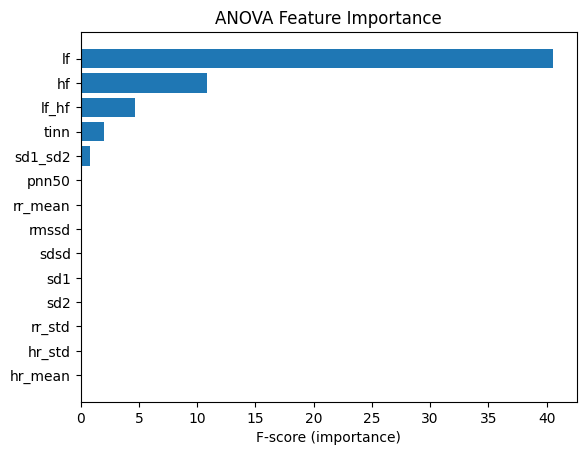

In [24]:
import matplotlib.pyplot as plt

# Sort again for plotting
names = [x[0] for x in anova_results]
f_scores = [x[1] for x in anova_results]

plt.figure()
plt.barh(names, f_scores)
plt.xlabel("F-score (importance)")
plt.title("ANOVA Feature Importance")
plt.gca().invert_yaxis()
plt.show()

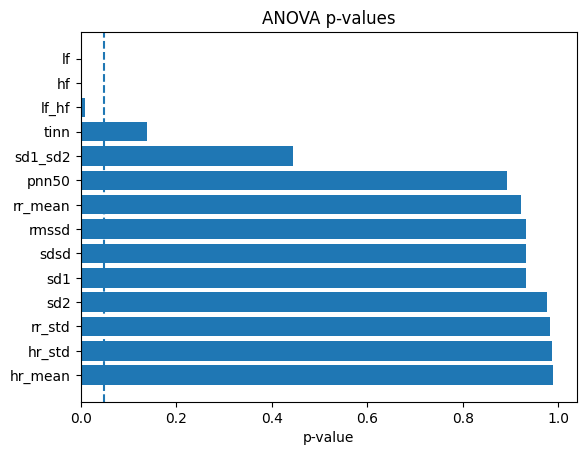

In [25]:
p_vals = [x[2] for x in anova_results]

plt.figure()
plt.barh(names, p_vals)
plt.xlabel("p-value")
plt.title("ANOVA p-values")
plt.gca().invert_yaxis()

# Optional: significance line
plt.axvline(x=0.05, linestyle='--')
plt.show()